## YOLOS模型应用开发

**环境配置：**
1. MindSpore 2.4.0
2. Mindnlp 0.4.1
3. Python 3.9

**使用华为云 ModelArts 作为AI平台**

在环境搭建部分，使用了AI gallery社区中相关mindnlp项目搭建mindnlp环境的代码。

### 1 环境配置

1. 配置python3.9环境
2. 安装mindspore2.3.1，安装指南详见：[MindSpore安装](https://www.mindspore.cn/install/)
3. 安装MindNLP及相关依赖，MindNLP官方仓详见：[MindNLP](https://github.com/mindspore-lab/mindnlp)

### 2 YOLOS模型

**YOLOS**（You Only Look at One Sequence）是一个基于**Vision Transformer (ViT)**的目标检测模型。它将图像分割成小块，并使用Transformer来处理这些小块，同时引入了目标检测查询（类似于检测标记）来预测图像中的物体。

- [论文](https://arxiv.org/abs/2106.00666) 详细介绍了 YOLOS 模型。
- [YOLOS 代码](https://github.com/hustvl/YOLOS) 可以在 GitHub 上找到实现。

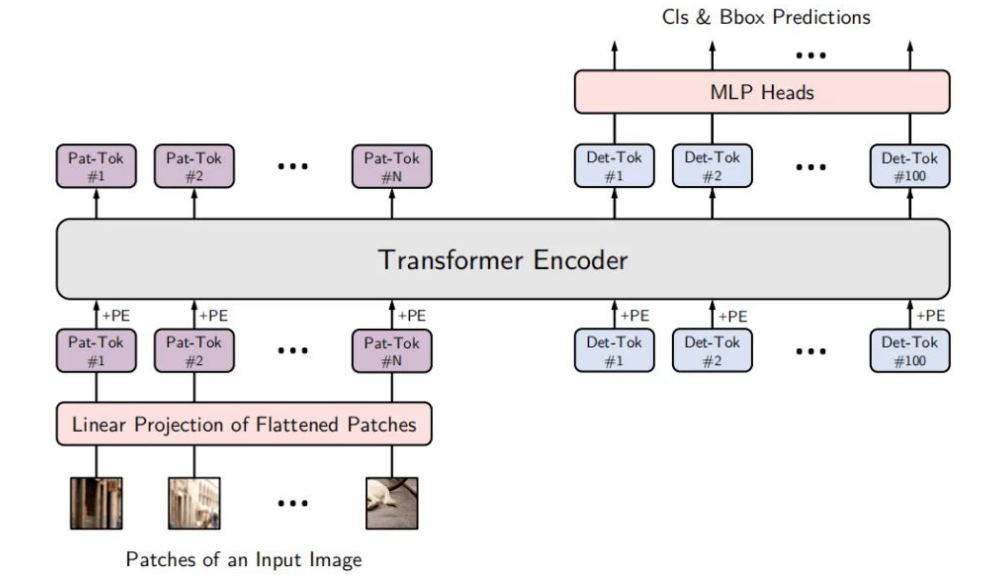


YOLOS 的主要特点是简化了传统目标检测方法，它不依赖于卷积神经网络（CNN）进行特征提取，而是直接使用ViT的自注意力机制来捕捉图像中的全局信息。与**DETR**模型类似，YOLOS采用了**双向匹配损失**来优化目标检测的效果，使得模型能够准确匹配预测目标和实际目标。

YOLOS 的优势在于结构简洁、易于扩展，且能通过端到端的训练方式直接从原始图像进行物体检测。缺点则是对计算资源要求较高，尤其是在处理高分辨率图像时。

#### 2.1 可以从中 `dir(mindnlp.transformers)` 查看和导入到关于VIT的包

In [ ]:
import mindnlp
dir(mindnlp.transformers)  

#### 2.2 基于YOLOS(You Only Look at One Sequence)模型进行目标检测
全流程

* 图像输入：准备输入图像。

* 模型推理：使用 YOLOS 模型对图像进行推理，生成每个查询位置的类别概率（logits）。

* 筛选高置信度结果：根据设定的置信度阈值（0.9），筛选出置信度高的预测结果。

* 边界框缩放：将模型输出的归一化边界框坐标缩放到原始图像的像素坐标。

* 结果可视化：在原始图像上绘制检测到的目标框，并标记类别和置信度。

* 展示结果：展示最终绘制的结果，显示图像中被检测的物体及其分类信息。

 1. 导入相关库

In [ ]:
from PIL import Image
import requests
import mindspore as ms
from mindnlp.transformers import YolosForObjectDetection, YolosFeatureExtractor
from mindspore import Tensor
import matplotlib.pyplot as plt

2. 加载图片、特征提取器和模型

In [ ]:
#图片可以自行替换
url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
image = Image.open(requests.get(url, stream=True).raw)
image

In [ ]:
feature_extractor = YolosFeatureExtractor.from_pretrained("hustvl/yolos-small")
model = YolosForObjectDetection.from_pretrained("hustvl/yolos-small")
model

3.预处理

对 image 进行特征提取，转换为 NumPy 数组格式

In [ ]:
pixel_values = feature_extractor(image, return_tensors="np").pixel_values
pixel_values.shape

将图像的像素值转换为张量格式传递给模型进行推理，并获取模型的输出结果

In [ ]:
pixel_values = Tensor(pixel_values)
outputs = model(pixel_values, output_attentions=True)
outputs

4.定义一个将检测结果可视化函数

In [ ]:
# 定义一组颜色用于可视化
COLORS = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(16,10))  # 创建一个大小为 16x10 的画布
    plt.imshow(pil_img)  # 将 PIL 图像显示在画布上
    ax = plt.gca()  # 获取当前的坐标轴对象
    colors = COLORS * 100  # 扩展 COLORS 列表，确保能覆盖所有边界框
    
    # 遍历每个目标的预测概率、边界框坐标和颜色
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors):
        # 添加一个矩形框（边界框）到图像中，表示检测到的目标位置
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        
        # 获取预测类别的最大概率对应的类别索引
        cl = p.argmax()  # 找到概率值最大的类别索引
        
        # 通过索引查找类别的名称和对应的置信度
        text = f'{model.config.id2label[cl.item()]}: {p[cl].item():0.2f}'
        
        # 在矩形框的左上角显示类别名称和对应的置信度
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))  # 设置文本框的背景颜色和透明度

    plt.axis('off')  # 关闭坐标轴显示
    plt.show()  # 显示图像

5.后处理

对目标检测的输出进行后处理，保留置信度大于 0.9 的检测框，并将它们的坐标按原始图像尺寸进行重新缩放。

In [ ]:
# 保留置信度大于 0.9 的查询预测
probas = outputs.logits.softmax(-1)[0, :, :-1]  # 对 logits 应用 softmax 激活函数并去掉最后一列（无物体类）
keep = probas.max(-1) > 0.9  # 筛选出置信度大于 0.9 的框

# 重新缩放边界框
target_sizes = ms.tensor(image.size[::-1]).unsqueeze(0)  # 将图像尺寸转换为张量，并增加一个维度
postprocessed_outputs = feature_extractor.post_process(outputs, target_sizes)  # 执行后处理
bboxes_scaled = postprocessed_outputs[0]['boxes']  # 获取重新缩放后的边界框

将筛选后的高置信度目标检测结果绘制到原始图像上

In [ ]:
plot_results(image, probas[keep], bboxes_scaled[keep])